In [3]:
import optuna
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import  petals

X_train, y_train = petals.training_data(N=1000, seed=37)
X_test, y_test = petals.training_data(N=1000, seed=42)

In [4]:
def objective(trial):
    params = {
        "max_iter": trial.suggest_int("max_iter", 100, 2000),
        "learning_rate": trial.suggest_float("learning_rate", 0.005, 0.2, log=True),
        "max_leaf_nodes": trial.suggest_int("max_leaf_nodes", 3, 63),
        "max_depth": trial.suggest_int("max_depth", 2, 12),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 5, 100),
        "l2_regularization": trial.suggest_float("l2_regularization", 1e-8, 10.0, log=True),
        "max_bins": trial.suggest_int("max_bins", 16, 255),
        "random_state": 37,
    }

    model = HistGradientBoostingRegressor(**params)
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    mse = mean_squared_error(y_test, y_pred)
    rmse = mse ** 0.5
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    miscalibration = y_pred.mean() - y_test.mean()
    accuracy = np.mean(y_test == np.rint(y_pred))

    trial.set_user_attr("mse", mse)
    trial.set_user_attr("rmse", rmse)
    trial.set_user_attr("mae", mae)
    trial.set_user_attr("r2", r2)
    trial.set_user_attr("miscalibration", miscalibration)
    trial.set_user_attr("accuracy", accuracy)

    return mse


sampler = optuna.samplers.TPESampler(seed=37)

study = optuna.create_study(
    direction="minimize",
    sampler=sampler,
)

study.optimize(objective, n_trials=100, show_progress_bar=True)

print("Best MSE:", study.best_value)
print("Best params:", study.best_params)

[I 2026-05-21 19:36:14,360] A new study created in memory with name: no-name-9df67e7d-f64e-4a14-b911-715be38b4e47


  0%|          | 0/100 [00:00<?, ?it/s]

[I 2026-05-21 19:36:20,723] Trial 0 finished with value: 0.032617790752185585 and parameters: {'max_iter': 1895, 'learning_rate': 0.02770021382056352, 'max_leaf_nodes': 14, 'max_depth': 8, 'min_samples_leaf': 64, 'l2_regularization': 0.014388521072426656, 'max_bins': 40}. Best is trial 0 with value: 0.032617790752185585.
[I 2026-05-21 19:36:25,525] Trial 1 finished with value: 0.07241858563548269 and parameters: {'max_iter': 1517, 'learning_rate': 0.014148727780206545, 'max_leaf_nodes': 48, 'max_depth': 10, 'min_samples_leaf': 65, 'l2_regularization': 9.803916280979927e-05, 'max_bins': 247}. Best is trial 0 with value: 0.032617790752185585.
[I 2026-05-21 19:36:30,739] Trial 2 finished with value: 0.12560671870426163 and parameters: {'max_iter': 1805, 'learning_rate': 0.010333853024112882, 'max_leaf_nodes': 39, 'max_depth': 8, 'min_samples_leaf': 72, 'l2_regularization': 2.30865036345865, 'max_bins': 28}. Best is trial 0 with value: 0.032617790752185585.
[I 2026-05-21 19:36:31,453] Tria

In [7]:
rows = []

for t in study.trials:
    row = {
        "trial": t.number,
        "target_mse": t.value,
        **t.params,
        **t.user_attrs,
    }
    rows.append(row)
    
trials_df = pd.DataFrame(rows).sort_values("target_mse").reset_index(drop=True)

pd.set_option('display.max_rows', None)
trials_df

,trial,target_mse,max_iter,learning_rate,max_leaf_nodes,max_depth,min_samples_leaf,l2_regularization,max_bins,mse,rmse,mae,r2,miscalibration,accuracy
0,11,0.000016,1268,0.163793,3,2,6,1.533541e-08,93,0.000016,0.004047,0.001996,0.999999,0.000424,1.000
1,47,0.000065,1776,0.071482,3,2,42,6.426297e-07,176,0.000065,0.008081,0.004900,0.999994,0.000428,1.000
2,61,0.000072,1089,0.114538,3,2,25,3.307574e-06,239,0.000072,0.008495,0.005416,0.999994,0.000738,1.000
3,51,0.000074,1710,0.071060,3,2,36,1.241291e-07,79,0.000074,0.008588,0.005429,0.999994,0.000421,1.000
4,96,0.000076,1309,0.108011,3,2,8,1.545016e-06,139,0.000076,0.008717,0.005083,0.999993,0.000544,1.000
5,58,0.000089,1031,0.128973,3,3,17,3.018263e-06,228,0.000089,0.009424,0.005667,0.999992,0.000415,1.000
6,63,0.000122,866,0.133078,3,2,24,8.038764e-07,77,0.000122,0.011051,0.006993,0.999990,0.000497,1.000
7,41,0.000123,1388,0.082359,3,2,8,2.303658e-06,29,0.000123,0.011081,0.007208,0.999989,0.000717,1.000
8,23,0.000125,1384,0.080015,3,2,14,4.528856e-05,111,0.000125,0.011202,0.007461,0.999989,0.000705,1.000
9,81,0.000133,947,0.108622,3,3,22,6.609610e-06,151,0.000133,0.011526,0.007501,0.999989,0.000827,1.000


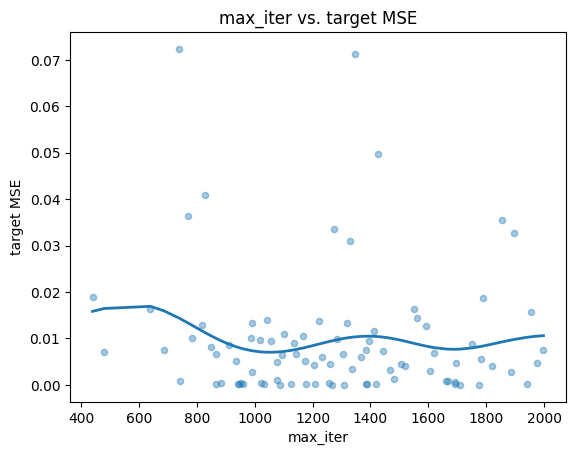

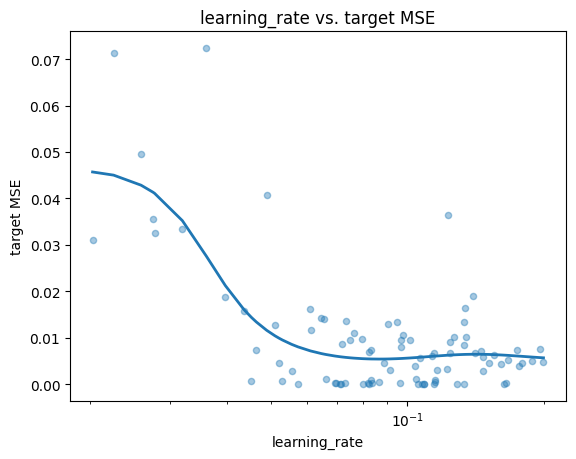

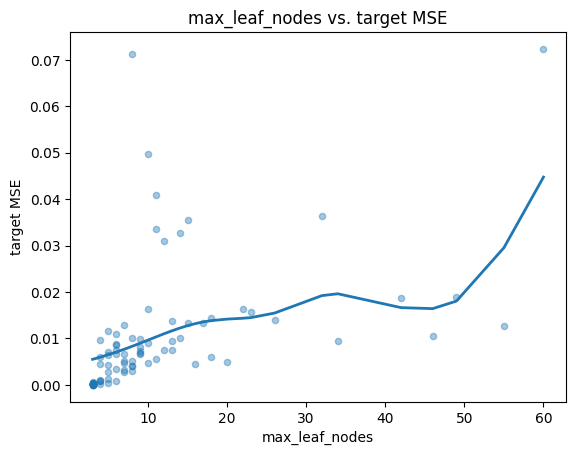

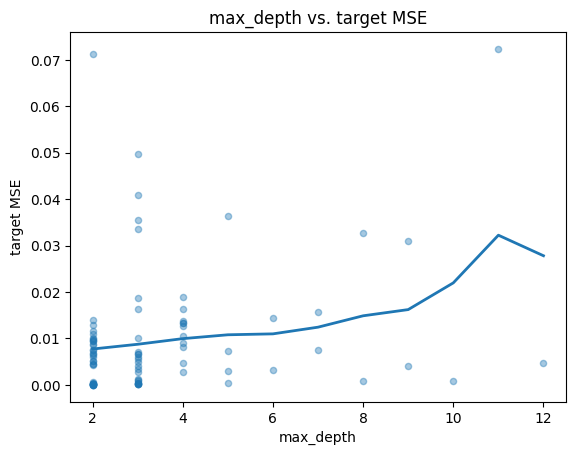

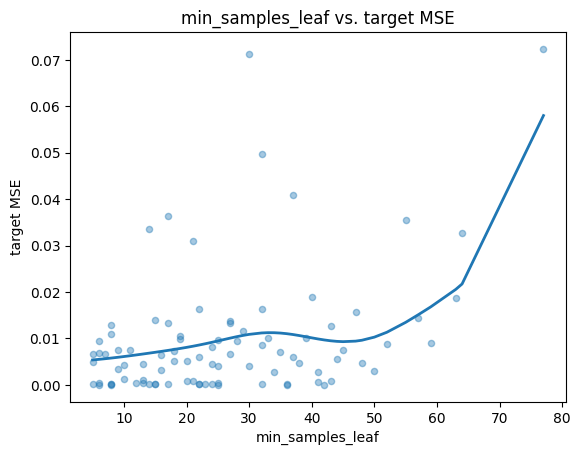

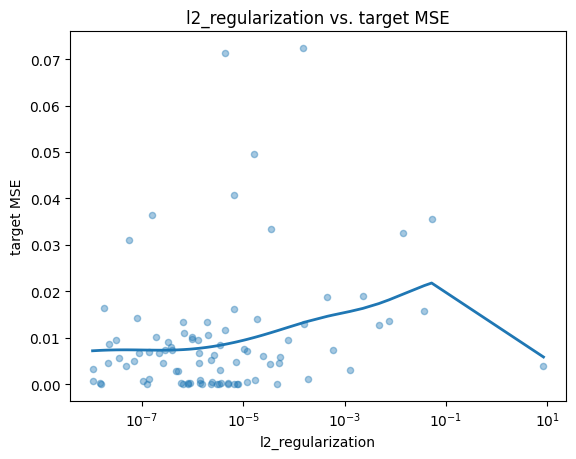

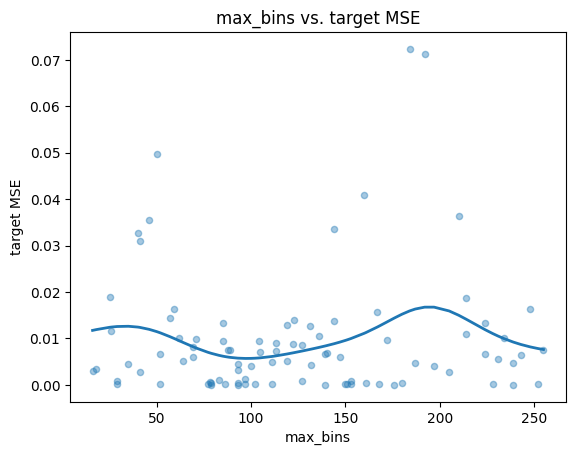

In [10]:
import numpy as np

for hp in hyperparams:
    plot_df = trials_df[[hp, "target_mse"]].dropna()

    # Remove worst 10% by target MSE
    cutoff = plot_df["target_mse"].quantile(0.90)
    plot_df = plot_df[plot_df["target_mse"] <= cutoff]

    x = plot_df[hp].to_numpy()
    y = plot_df["target_mse"].to_numpy()

    # Work in log space for log-scaled hyperparameters
    if hp in {"learning_rate", "l2_regularization"}:
        x_smooth_space = np.log10(x)
    else:
        x_smooth_space = x

    # Sort for plotting/smoothing
    order = np.argsort(x_smooth_space)
    x = x[order]
    y = y[order]
    x_smooth_space = x_smooth_space[order]

    # Bandwidth ≈ 10% of x-axis span
    bandwidth = 0.10 * (x_smooth_space.max() - x_smooth_space.min())

    # Gaussian-weighted exponential smoothing
    y_smooth = np.empty_like(y)

    for i, xi in enumerate(x_smooth_space):
        weights = np.exp(-0.5 * ((x_smooth_space - xi) / bandwidth) ** 2)
        y_smooth[i] = np.sum(weights * y) / np.sum(weights)

    plt.figure()
    plt.title(f"{hp} vs. target MSE")
    plt.xlabel(hp)
    plt.ylabel("target MSE")

    if hp in {"learning_rate", "l2_regularization"}:
        plt.xscale("log")

    plt.scatter(x, y, alpha=0.4, s=20)
    plt.plot(x, y_smooth, linewidth=2)

    plt.show()

Best hyperparameters: {'max_iter': 1268, 'learning_rate': 0.16379302966980017, 'max_leaf_nodes': 3, 'max_depth': 2, 'min_samples_leaf': 6, 'l2_regularization': 1.5335407616629294e-08, 'max_bins': 93}
MAE: 0.00580467491264203
RMSE: 0.008050942839042296
R2: 0.9999944500544742
miscalibration: 0.000


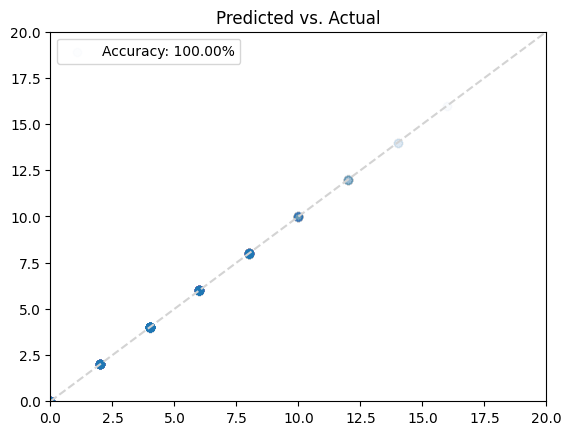

In [26]:
def train_best_model(N):
    X_train, y_train = petals.training_data(N=N, seed=37)
    X_test, y_test = petals.training_data(N=1000, seed=42)

    best_params = (
        trials_df
        .sort_values("target_mse", ascending=True)
        .iloc[0][hyperparams]
        .to_dict()
    )

    # Cast integer-valued hyperparameters back to int
    for hp in [
        "max_iter",
        "max_leaf_nodes",
        "max_depth",
        "min_samples_leaf",
        "max_bins",
    ]:
        if hp in best_params and not pd.isna(best_params[hp]):
            best_params[hp] = int(best_params[hp])

    # Drop NaNs, e.g. max_depth=None if it was not used
    best_params = {
        k: v for k, v in best_params.items()
        if not pd.isna(v)
    }

    model = HistGradientBoostingRegressor(
        **best_params,
        random_state=37
    )

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    print("Best hyperparameters:", best_params)
    print("MAE:", mean_absolute_error(y_test, y_pred))
    print("RMSE:", mean_squared_error(y_test, y_pred) ** 0.5)
    print("R2:", r2_score(y_test, y_pred))
    print(f"miscalibration: {y_pred.mean() - y_test.mean():0.3f}")

    accuracy = np.mean(y_test == np.rint(y_pred))

    plt.title("Predicted vs. Actual")
    plt.ylim(0, 20)
    plt.xlim(0, 20)
    plt.scatter(y_test, y_pred, alpha=10 / len(y_test))
    plt.plot([0, 20], [0, 20], linestyle="--", color="lightgray")
    plt.legend([f"Accuracy: {accuracy * 100:.2f}%"])

    return model

model = train_best_model(N=250)

In [27]:
(
    trials_df
    .sort_values("target_mse", ascending=True)
    .iloc[0][hyperparams]
    .to_dict()
)

{'max_iter': 1268.0,
 'learning_rate': 0.16379302966980017,
 'max_leaf_nodes': 3.0,
 'max_depth': 2.0,
 'min_samples_leaf': 6.0,
 'l2_regularization': 1.5335407616629294e-08,
 'max_bins': 93.0}

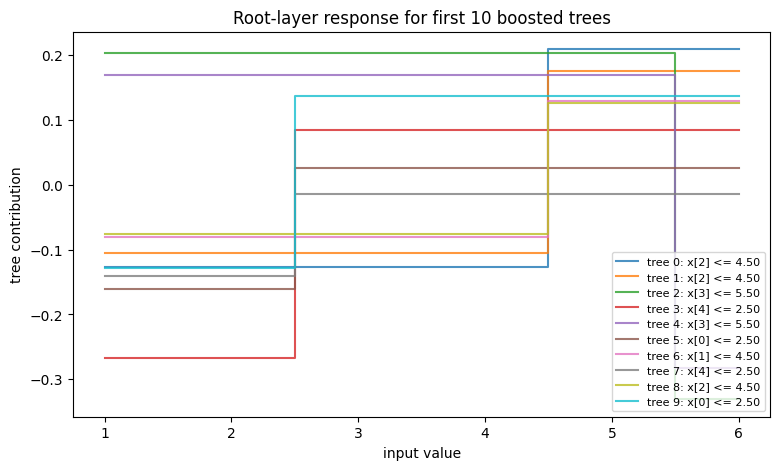

In [30]:
import numpy as np
import matplotlib.pyplot as plt

def subtree_mean_value(nodes, node_id):
    node = nodes[node_id]

    if node["is_leaf"]:
        return node["value"]

    return 0.5 * (
        subtree_mean_value(nodes, node["left"]) +
        subtree_mean_value(nodes, node["right"])
    )

def root_layer_response(model, tree_idx, x_values, class_idx=0):
    tree = model._predictors[tree_idx][class_idx]
    nodes = tree.nodes
    root = nodes[0]

    threshold = root["num_threshold"]

    left_value = subtree_mean_value(nodes, root["left"])
    right_value = subtree_mean_value(nodes, root["right"])

    y = np.where(x_values <= threshold, left_value, right_value)

    return y, root["feature_idx"], threshold

x_values = np.arange(1, 7)

plt.figure(figsize=(9, 5))

for tree_idx in range(10):
    y, feature_idx, threshold = root_layer_response(model, tree_idx, x_values)

    plt.step(
        x_values,
        y,
        where="mid",
        label=f"tree {tree_idx}: x[{feature_idx}] <= {threshold:.2f}",
        alpha=0.8,
    )

plt.title("Root-layer response for first 10 boosted trees")
plt.xlabel("input value")
plt.ylabel("tree contribution")
plt.xticks(x_values)
plt.legend(fontsize=8)
plt.show()

In [36]:
for i in range(1, 7):
    print( i, model.predict( np.array([[i, i, i, i, i]]) ) )

1 [-0.00801151]
2 [-9.1766126e-05]
3 [9.96704822]
4 [0.01015504]
5 [19.99915944]
6 [0.00371269]


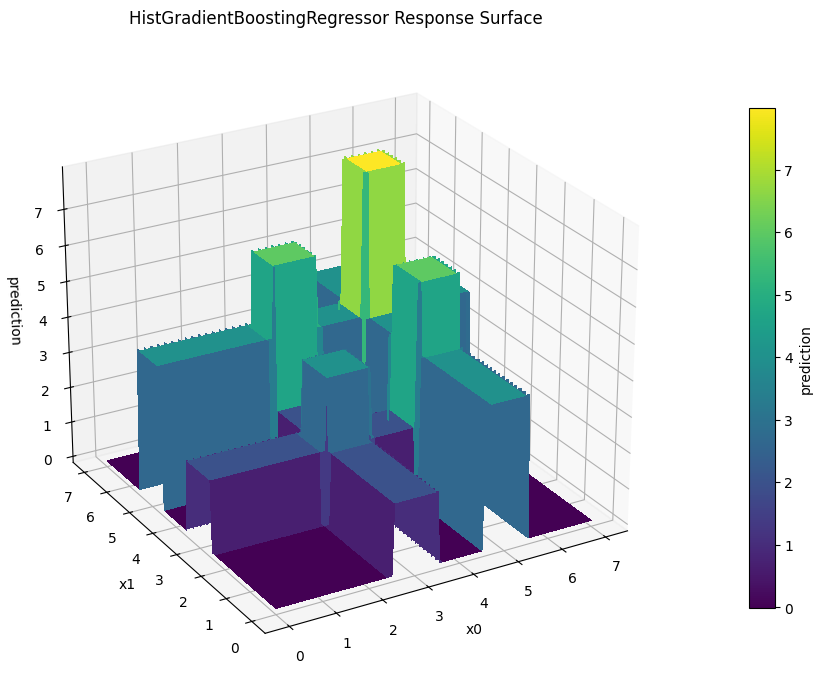

In [74]:
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.colors import Normalize
from matplotlib import cm

step = 0.05

# Build mesh grid
xs = np.arange(0, 7.01, step)
ys = np.arange(0, 7.01, step)

X, Y = np.meshgrid(xs, ys)

# Evaluate model on grid
points = np.column_stack([
    X.ravel(),
    Y.ravel(),
    np.ones(X.size),
    np.ones(X.size),
    np.ones(X.size),
])

Z = model.predict(points).reshape(X.shape)

# for 3d bar
# xpos = X.ravel()
# ypos = Y.ravel()
# zpos = np.zeros_like(xpos)
# dx = step * np.ones_like(zpos)
# dy = step * np.ones_like(zpos)
# dz = Z.ravel()
# norm = Normalize(vmin=dz.min(), vmax=dz.max())
# colors = cm.viridis(norm(dz))

# Plot
fig = plt.figure(figsize=(9, 8))
ax = fig.add_subplot(111, projection="3d")

surf = ax.plot_surface(
    X,
    Y,
    Z,
    cmap="viridis",
    linewidth=0,
    antialiased=False,
    shade=True,
)

# ax.bar3d(
#     xpos,
#     ypos,
#     zpos,
#     dx,
#     dy,
#     dz,
#     color=colors,
#     shade=True,
#     zsort="average",
# )

ax.set_title("HistGradientBoostingRegressor Response Surface")

ax.set_xlabel("x0")
ax.set_ylabel("x1")
ax.set_zlabel("prediction")

# perspective
ax.view_init(elev=25, azim=-120)

# Similar aspect ratio
ax.set_box_aspect((1, 1, 0.8))

# Colorbar
fig.colorbar(
    surf,
    ax=ax,
    shrink=0.65,
    pad=0.1,
    label="prediction"
)

plt.tight_layout()
plt.show()

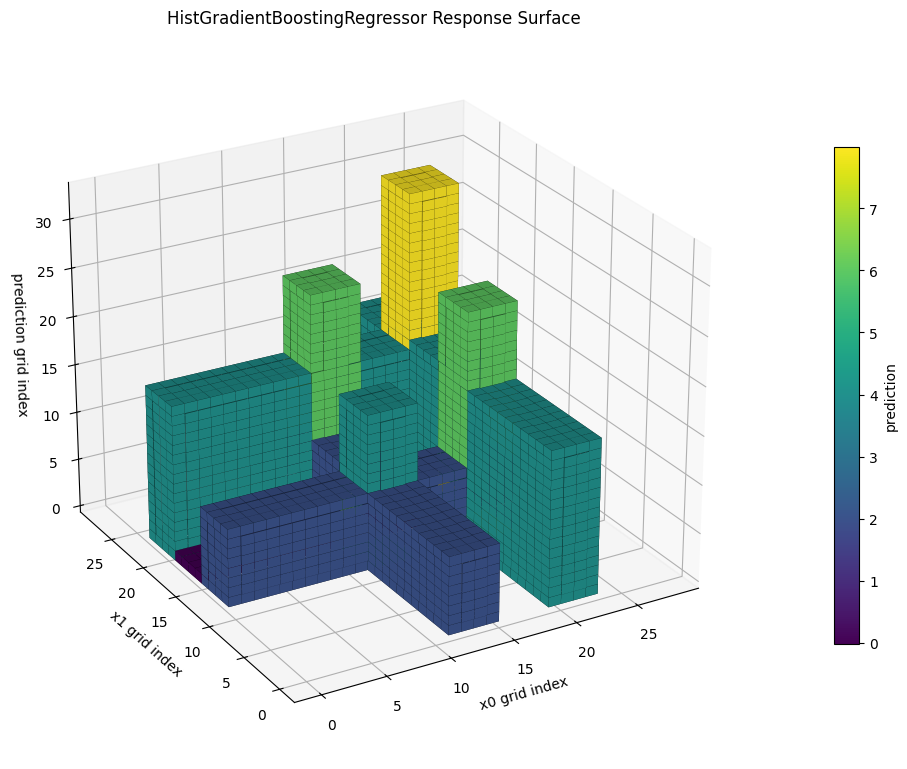

In [79]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.colors import Normalize
from mpl_toolkits.mplot3d import Axes3D

# ------------------------------------------------------------------
# Build grid
# ------------------------------------------------------------------

step = 0.25

xs = np.arange(0, 7.00, step)
ys = np.arange(0, 7.00, step)

X, Y = np.meshgrid(xs, ys)

# ------------------------------------------------------------------
# Evaluate model
# ------------------------------------------------------------------

points = np.column_stack([
    X.ravel(),
    Y.ravel(),
    np.ones(X.size),
    np.ones(X.size),
    np.ones(X.size),
])

Z = model.predict(points).reshape(X.shape)

# ------------------------------------------------------------------
# Convert heights to voxel occupancy
# ------------------------------------------------------------------

z_step = 0.25
zs = np.arange(0, Z.max() + z_step, z_step)

filled = zs[:, None, None] <= Z[None, :, :]

# Matplotlib voxels expects shape as (nx, ny, nz), so transpose
filled = np.transpose(filled, (2, 1, 0))

# Color each vertical column by prediction height
norm = Normalize(vmin=Z.min(), vmax=Z.max())
column_colors = cm.viridis(norm(Z))

facecolors = np.empty(filled.shape + (4,))
facecolors[:] = (0, 0, 0, 0)

for i in range(filled.shape[0]):
    for j in range(filled.shape[1]):
        facecolors[i, j, :, :] = column_colors[j, i]

# ------------------------------------------------------------------
# Plot
# ------------------------------------------------------------------

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection="3d")

ax.voxels(
    filled,
    facecolors=facecolors,
    edgecolor="k",
    linewidth=0.05,
    shade=True,
)

ax.set_title("HistGradientBoostingRegressor Response Surface")

ax.set_xlabel("x0 grid index")
ax.set_ylabel("x1 grid index")
ax.set_zlabel("prediction grid index")

ax.view_init(elev=25, azim=-120)
ax.set_box_aspect((1, 1, 0.8))

mappable = cm.ScalarMappable(norm=norm, cmap="viridis")
mappable.set_array([])

fig.colorbar(
    mappable,
    ax=ax,
    shrink=0.65,
    pad=0.1,
    label="prediction"
)

plt.tight_layout()
plt.show()

In [44]:
import plotly.io as pio
import plotly.graph_objects as go

pio.renderers.default = "iframe"

In [45]:
xs = np.arange(0, 7.01, 0.1)
ys = np.arange(0, 7.01, 0.1)

X, Y = np.meshgrid(xs, ys)

points = np.column_stack([
    X.ravel(),
    Y.ravel(),
    np.ones(X.size),
    np.ones(X.size),
    np.ones(X.size),
])

Z = model.predict(points).reshape(X.shape)

fig = go.Figure(
    data=[
        go.Surface(
            x=X,
            y=Y,
            z=Z,
            colorscale="Viridis",
        )
    ]
)

fig.update_layout(
    title="HistGradientBoostingRegressor Response Surface",
    scene=dict(
        xaxis_title="x0",
        yaxis_title="x1",
        zaxis_title="prediction",
    ),
    width=900,
    height=700,
)

fig.show()